# Analyse du Dataset *Online Retail*  
### Rapport ETL & Analyse Exploratoire  
**Auteur : Lamine**  

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.etl_pipeline import ETLPipeline

plt.style.use("seaborn-v0_8")

## Chargement du pipeline ETL


In [2]:
BASE_DIR = os.getcwd()

retail_path = os.path.join(BASE_DIR, "Data", "Online_Retail.xlsx")
supplier_path = os.path.join(BASE_DIR, "Data", "Supplier.csv")
continent_path = os.path.join(BASE_DIR, "Data", "continent_df.csv")

pipeline = ETLPipeline(
    retail_path=retail_path,
    supplier_path=supplier_path,
    continent_path=continent_path
)

pipeline.run_pipeline()

df = pipeline.df
results = pipeline.results

df.shape 
#list(results.keys())


Top 5 pays par ventes :
       Country  TotalAmount
United Kingdom  7285024.644
   Netherlands   285446.340
          EIRE   265262.460
       Germany   228678.400
        France   208934.310


(392692, 9)

## dataset nettoyé


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


## Top 10 des pays à plus de Ventes

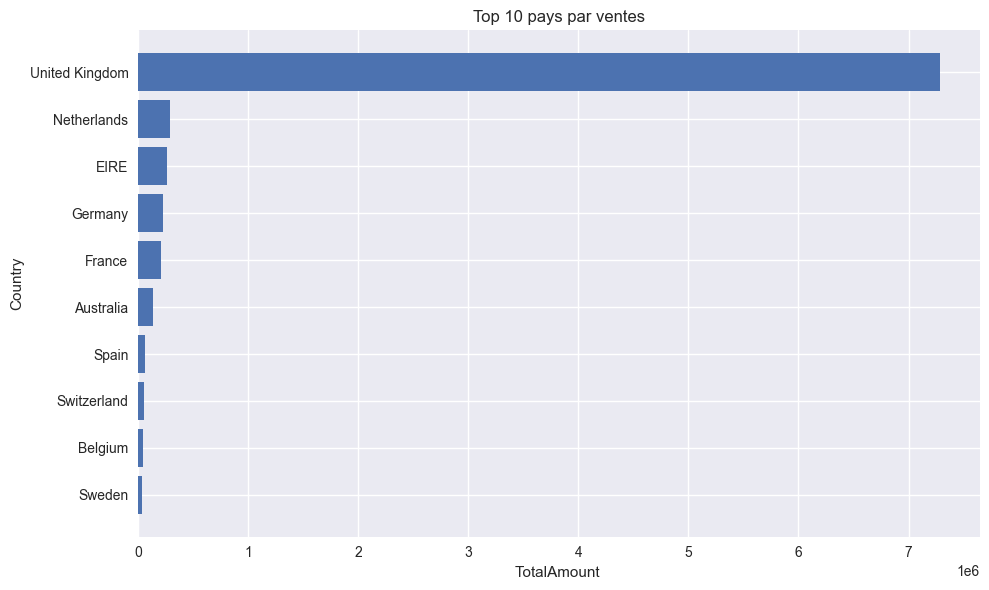

,Country,TotalAmount
35,United Kingdom,7285024.644
23,Netherlands,285446.340
10,EIRE,265262.460
14,Germany,228678.400
13,France,208934.310
0,Australia,138453.810
30,Spain,61558.560
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38367.830


In [33]:
country_sales = results["country_sales"].head(10)

plt.figure(figsize=(10, 6))
plt.barh(country_sales["Country"], country_sales["TotalAmount"])
plt.gca().invert_yaxis()
plt.title("Top 10 pays par ventes")
plt.xlabel("TotalAmount ")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

country_sales


## Evolution des ventes

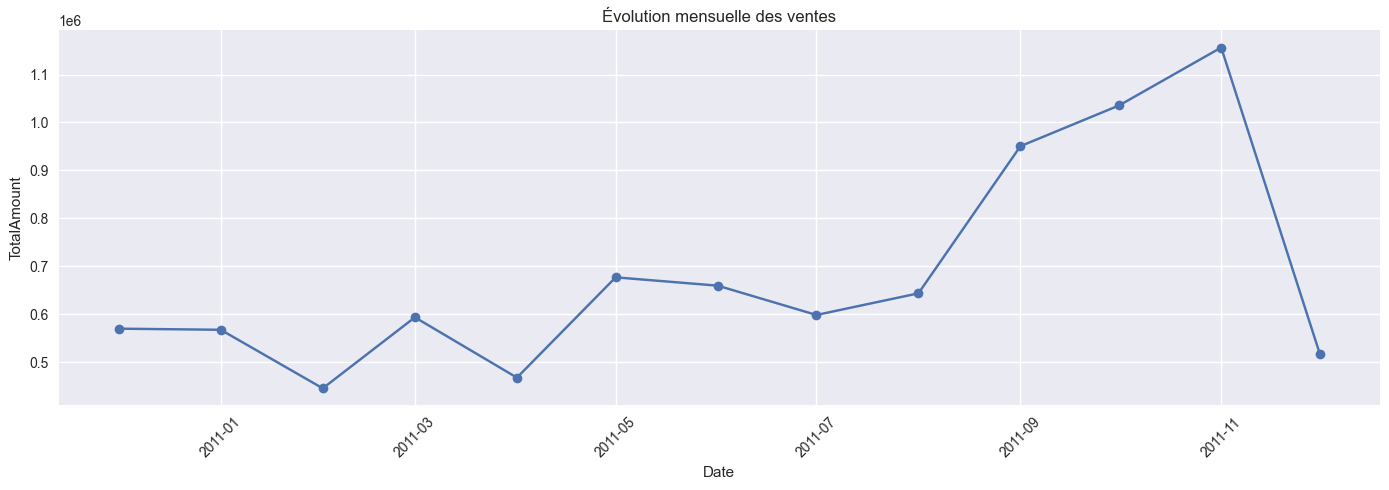

In [7]:
monthly = results["monthly_stats"].copy()
monthly["YearMonth"] = monthly["YearMonth"].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly["YearMonth"], monthly["TotalAmount"], marker="o")
plt.xticks(rotation=45)
plt.title("Évolution mensuelle des ventes")
plt.xlabel("Date")
plt.ylabel("TotalAmount")
plt.tight_layout()
plt.show()


## Classement de la description en fonction du total de ventes en France

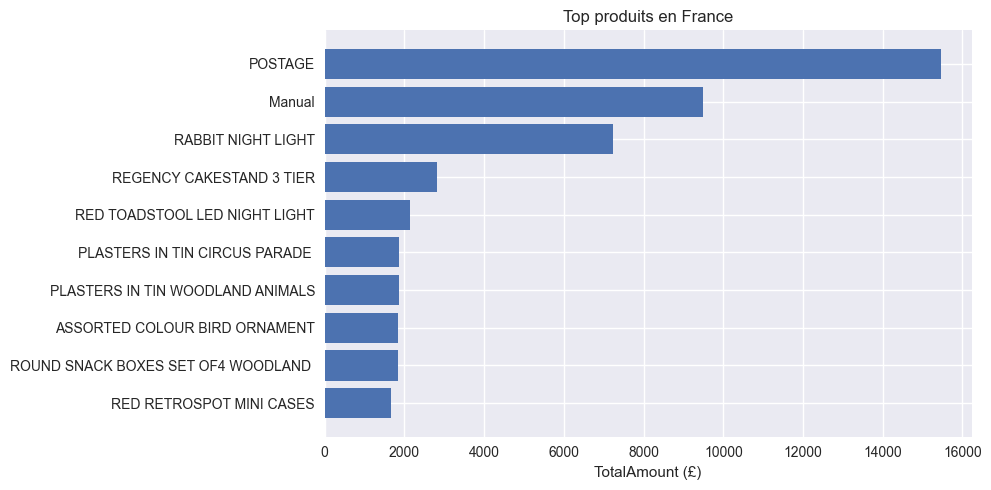

,Description,TotalAmount
964,POSTAGE,15454.00
782,Manual,9492.37
972,RABBIT NIGHT LIGHT,7234.24
1052,REGENCY CAKESTAND 3 TIER,2816.85
1046,RED TOADSTOOL LED NIGHT LIGHT,2130.15
941,PLASTERS IN TIN CIRCUS PARADE,1868.40
946,PLASTERS IN TIN WOODLAND ANIMALS,1866.75
85,ASSORTED COLOUR BIRD ORNAMENT,1842.76
1109,ROUND SNACK BOXES SET OF4 WOODLAND,1837.80
1020,RED RETROSPOT MINI CASES,1662.90


In [ ]:
top_fr = results["stat_data"]["top_product_france"]

plt.figure(figsize=(10, 5))
plt.barh(top_fr["Description"].head(10), top_fr["TotalAmount"].head(10))
plt.gca().invert_yaxis()
plt.title("Top produits en France")
plt.xlabel("TotalAmount")
plt.tight_layout()
plt.show()

top_fr.head(10)

### analyse des heure de pointes en Fance

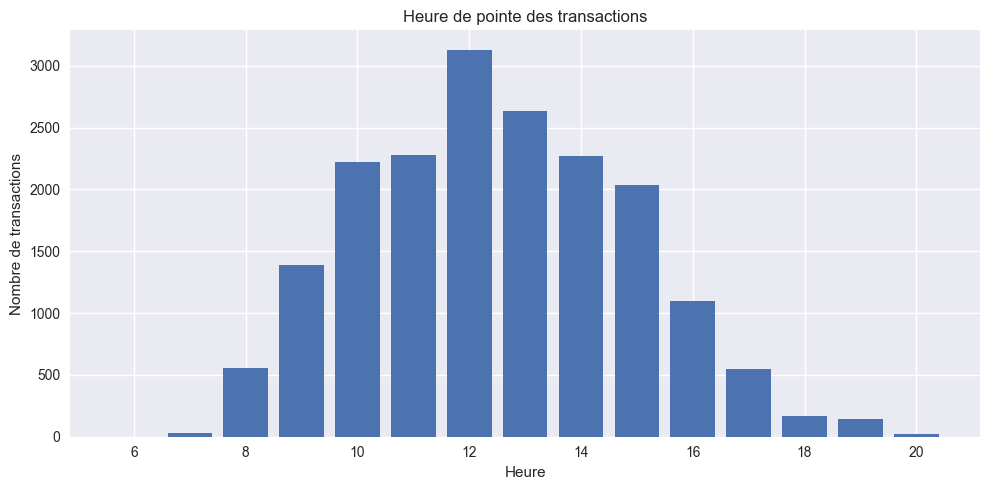

,Hour,NbTransactions
6,12,3130
7,13,2636
5,11,2277
8,14,2274
4,10,2226


In [36]:
peak_hour = results["stat_data"]["peak_hour"]

plt.figure(figsize=(10, 5))
plt.bar(peak_hour["Hour"], peak_hour["NbTransactions"])
plt.title("Heure de pointe des transactions")
plt.xlabel("Heure")
plt.ylabel("Nombre de transactions")
plt.tight_layout()
plt.show()

peak_hour.head()


### Fourniseur en fonction des ventes

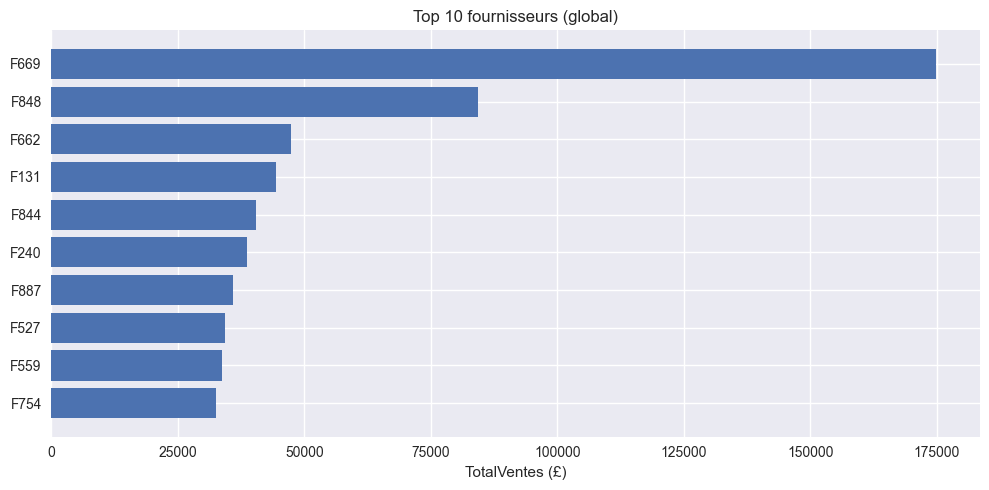

,Fournisseur,TotalVentes
569,F669,174791.03
748,F848,84350.62
562,F662,47311.55
31,F131,44412.29
744,F844,40473.59
140,F240,38644.26
787,F887,35994.92
427,F527,34266.39
459,F559,33666.80
654,F754,32610.03


In [37]:
global_sup = results["supplier_data"]["global_ranking"].head(10)

plt.figure(figsize=(10, 5))
plt.barh(global_sup["Fournisseur"], global_sup["TotalVentes"])
plt.gca().invert_yaxis()
plt.title("Top 10 fournisseurs (global)")
plt.xlabel("TotalVentes (£)")
plt.tight_layout()
plt.show()

global_sup

## les dépenses par continent

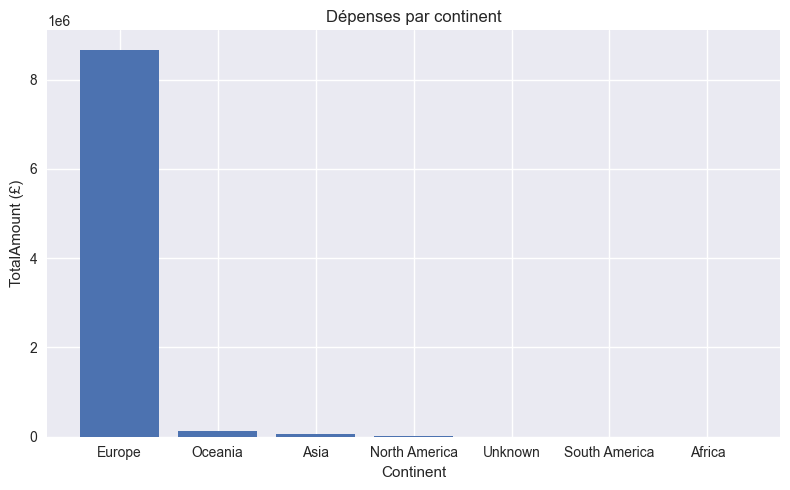

,Continent,TotalAmount
2,Europe,8666499.654
4,Oceania,138453.810
1,Asia,70201.980
3,North America,7246.770
6,Unknown,2660.770
5,South America,1143.600
0,Africa,1002.310


In [38]:
continent_spending = results["world_data"]["continent_spending"]

plt.figure(figsize=(8, 5))
plt.bar(continent_spending["Continent"], continent_spending["TotalAmount"])
plt.title("Dépenses par continent")
plt.xlabel("Continent")
plt.ylabel("TotalAmount (£)")
plt.tight_layout()
plt.show()

continent_spending